# Construction des groupes d’assurance collaborative

Ce notebook construit des groupes d’assurés présentant des caractéristiques similaires.

Le clustering utilise uniquement les variables de profil disponibles avant les sinistres. Les sinistres réels et les variables cibles sont exclus.

Les scores prédits seront utilisés après le clustering afin :

- de caractériser le risque de chaque segment ;
- d’éviter une concentration excessive des profils risqués ;
- de construire des groupes collaboratifs équilibrés.

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [80]:
cleaned_data_path = Path(
    "../data/processed/cleaned_data.csv"
)

risk_scores_path = Path(
    "../data/processed/risk_scores_year5.csv"
)

In [81]:
df = pd.read_csv(
    cleaned_data_path
)

risk_scores = pd.read_csv(
    risk_scores_path
)

In [82]:
print(
    "Dataset nettoyé :",
    df.shape
)

print(
    "Scores de risque :",
    risk_scores.shape
)

Dataset nettoyé : (122935, 26)
Scores de risque : (13284, 11)


In [83]:
year5_profiles = df.loc[
    df["year"] == 5
].copy()

In [84]:
assert (
    year5_profiles["PolID"].is_unique
)

assert (
    risk_scores["PolID"].is_unique
)

print(
    "Un contrat correspond à une seule "
    "observation en année 5."
)

Un contrat correspond à une seule observation en année 5.


In [85]:
clustering_data = year5_profiles.merge(
    risk_scores[
        [
            "PolID",
            "year",
            "Predicted_Claim_Probability",
            "Predicted_Frequency",
            "Predicted_Severity",
            "Predicted_Expected_Cost",
            "Risk_Decile",
            "Risk_Level"
        ]
    ],
    on=[
        "PolID",
        "year"
    ],
    how="inner",
    validate="one_to_one"
)

In [86]:
print(
    "Dimensions après fusion :",
    clustering_data.shape
)

assert (
    len(clustering_data)
    == len(year5_profiles)
    == len(risk_scores)
)

print(
    "Tous les contrats de l'année 5 "
    "ont un score de risque."
)

Dimensions après fusion : (13284, 32)
Tous les contrats de l'année 5 ont un score de risque.


In [87]:
clustering_features = [
    "gender",
    "Age_client",
    "age_of_car_M",
    "Car_power_M",
    "Car_2ndDriver_M",
    "num_policiesC",
    "metro_code",
    "Policy_PaymentMethodA",
    "Policy_PaymentMethodH",
    "Insuredcapital_content_re",
    "Insuredcapital_continent_re",
    "appartment",
    "Client_Seniority"
]

In [88]:
X_clustering = clustering_data[
    clustering_features
].copy()

In [89]:
assert not X_clustering.isnull().any().any()

print(
    "Dimensions de la matrice de clustering :",
    X_clustering.shape
)

Dimensions de la matrice de clustering : (13284, 13)


## Variables de clustering

Les groupes sont construits avec les caractéristiques de l’assuré, du véhicule, du logement et du contrat.

Les variables suivantes sont exclues :

- `PolID`, car il s’agit d’un identifiant ;
- `year`, car tous les profils appartiennent à l’année 5 ;
- `Types`, car elle révèle des informations sur les sinistres ;
- `Retention`, car sa disponibilité temporelle n’est pas confirmée ;
- les nombres et les coûts réels des sinistres ;
- les scores de risque prédits.

Les scores prédits seront utilisés uniquement après le clustering pour caractériser et équilibrer les groupes.

In [90]:
clustering_scaler = StandardScaler()

In [91]:
X_clustering_scaled = (
    clustering_scaler.fit_transform(
        X_clustering
    )
)

In [92]:
X_clustering_scaled = pd.DataFrame(
    X_clustering_scaled,
    columns=clustering_features,
    index=X_clustering.index
)

In [93]:
scaling_check = pd.DataFrame({
    "Moyenne": (
        X_clustering_scaled.mean()
    ),
    "Ecart_type": (
        X_clustering_scaled.std(
            ddof=0
        )
    )
})

scaling_check.round(3)

,Moyenne,Ecart_type
gender,-0.0,1.0
Age_client,-0.0,1.0
age_of_car_M,0.0,1.0
Car_power_M,0.0,1.0
Car_2ndDriver_M,-0.0,1.0
num_policiesC,-0.0,1.0
metro_code,0.0,1.0
Policy_PaymentMethodA,-0.0,1.0
Policy_PaymentMethodH,0.0,1.0
Insuredcapital_content_re,0.0,1.0


### Limite de K-Means

K-Means utilise une distance euclidienne et est principalement conçu pour des variables numériques continues.

Dans cette baseline, les variables binaires sont standardisées avec les variables numériques afin d’éviter qu’une échelle particulière domine la distance.

Cette approche reste une approximation pour des données mixtes. La stabilité et l’interprétabilité des groupes seront vérifiées avant leur utilisation.

In [94]:
k_values = range(2, 11)

clustering_evaluation = []

In [95]:
for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )

    cluster_labels = model.fit_predict(
        X_clustering_scaled
    )

    silhouette = silhouette_score(
        X_clustering_scaled,
        cluster_labels,
        sample_size=min(
            5000,
            len(X_clustering_scaled)
        ),
        random_state=42
    )

    clustering_evaluation.append({
        "K": k,
        "Inertie": model.inertia_,
        "Silhouette": silhouette
    })

In [96]:
clustering_evaluation_df = pd.DataFrame(
    clustering_evaluation
)

clustering_evaluation_df.round(4)

,K,Inertie,Silhouette
0,2,156153.8371,0.1093
1,3,142501.1264,0.1220
2,4,132809.6032,0.1186
3,5,123125.5826,0.1305
4,6,115556.6492,0.1311
5,7,109215.0622,0.1305
6,8,104485.3018,0.1262
7,9,100743.9840,0.1257
8,10,97343.5432,0.1210


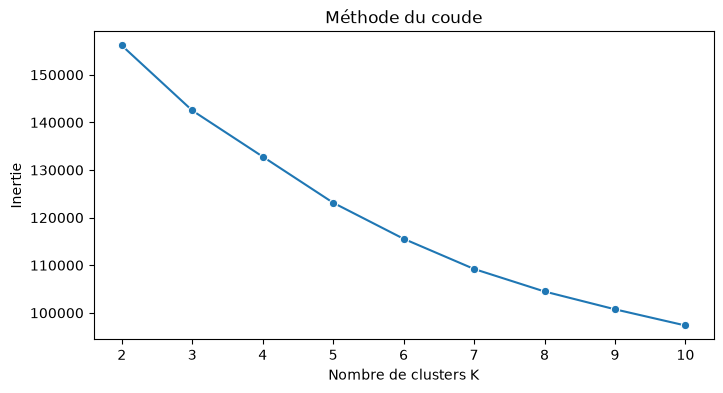

In [97]:
plt.figure(figsize=(8, 4))

sns.lineplot(
    data=clustering_evaluation_df,
    x="K",
    y="Inertie",
    marker="o"
)

plt.title(
    "Méthode du coude"
)
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie")
plt.xticks(list(k_values))
plt.show()

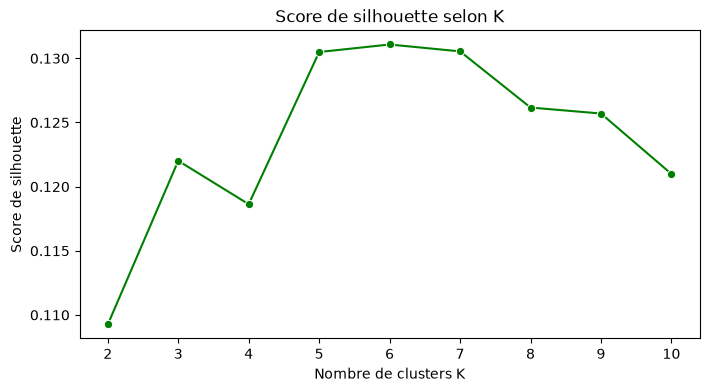

In [98]:
plt.figure(figsize=(8, 4))

sns.lineplot(
    data=clustering_evaluation_df,
    x="K",
    y="Silhouette",
    marker="o",
    color="green"
)

plt.title(
    "Score de silhouette selon K"
)
plt.xlabel("Nombre de clusters K")
plt.ylabel("Score de silhouette")
plt.xticks(list(k_values))
plt.show()

In [99]:
best_k_silhouette = int(
    clustering_evaluation_df.loc[
        clustering_evaluation_df[
            "Silhouette"
        ].idxmax(),
        "K"
    ]
)

print(
    "Meilleur nombre de clusters selon "
    f"la silhouette : {best_k_silhouette}"
)

Meilleur nombre de clusters selon la silhouette : 6


In [100]:
final_kmeans = KMeans(
    n_clusters=best_k_silhouette,
    n_init=50,
    random_state=42
)

In [101]:
final_cluster_labels = (
    final_kmeans.fit_predict(
        X_clustering_scaled
    )
)

In [102]:
clustering_data["Cluster"] = (
    final_cluster_labels
)

In [103]:
clustering_data["Cluster_Label"] = (
    clustering_data["Cluster"] + 1
)

In [104]:
clustering_data[
    [
        "PolID",
        "Cluster",
        "Cluster_Label"
    ]
].head()

,PolID,Cluster,Cluster_Label
0,1,5,6
1,3,5,6
2,4,5,6
3,11,5,6
4,15,3,4


In [105]:
cluster_sizes = (
    clustering_data[
        "Cluster_Label"
    ]
    .value_counts()
    .sort_index()
)

In [106]:
cluster_proportions = (
    clustering_data[
        "Cluster_Label"
    ]
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
)

In [107]:
cluster_size_summary = pd.DataFrame({
    "Nombre_contrats": cluster_sizes,
    "Pourcentage": cluster_proportions
})

cluster_size_summary.round(2)

,Nombre_contrats,Pourcentage
Cluster_Label,,
1,1470,11.07
2,2930,22.06
3,876,6.59
4,1582,11.91
5,4336,32.64
6,2090,15.73


In [108]:
assert cluster_sizes.sum() == len(
    clustering_data
)

print(
    "Tous les contrats sont affectés "
    "à un cluster."
)

Tous les contrats sont affectés à un cluster.


In [109]:
cluster_size_plot = (
    cluster_size_summary
    .reset_index()
)

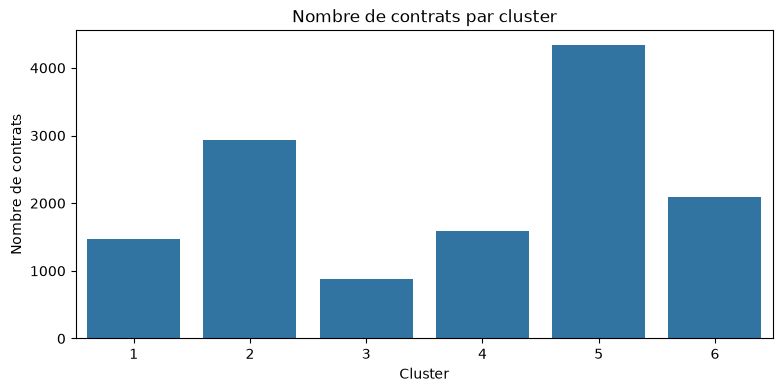

In [110]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=cluster_size_plot,
    x="Cluster_Label",
    y="Nombre_contrats"
)

plt.title(
    "Nombre de contrats par cluster"
)
plt.xlabel("Cluster")
plt.ylabel("Nombre de contrats")
plt.show()

In [111]:
numerical_cluster_features = [
    "Age_client",
    "age_of_car_M",
    "Car_power_M",
    "Insuredcapital_content_re",
    "Insuredcapital_continent_re",
    "Client_Seniority"
]

In [112]:
cluster_numerical_profile = (
    clustering_data
    .groupby("Cluster_Label")[
        numerical_cluster_features
    ]
    .mean()
)

cluster_numerical_profile.round(2)

,Age_client,age_of_car_M,Car_power_M,Insuredcapital_content_re,Insuredcapital_continent_re,Client_Seniority
Cluster_Label,,,,,,
1,59.59,9.81,104.82,10.38,11.48,10.39
2,62.03,11.24,115.47,10.43,12.08,8.71
3,58.14,9.80,111.82,10.58,11.94,9.51
4,63.15,9.83,122.91,10.46,11.31,10.53
5,58.72,11.67,114.97,10.23,11.16,8.33
6,69.85,3.26,93.62,10.23,11.36,18.10


In [113]:
binary_cluster_features = [
    "gender",
    "Car_2ndDriver_M",
    "num_policiesC",
    "metro_code",
    "Policy_PaymentMethodA",
    "Policy_PaymentMethodH",
    "appartment"
]

In [114]:
cluster_binary_profile = (
    clustering_data
    .groupby("Cluster_Label")[
        binary_cluster_features
    ]
    .mean()
    .mul(100)
)

cluster_binary_profile.round(2)

,gender,Car_2ndDriver_M,num_policiesC,metro_code,Policy_PaymentMethodA,Policy_PaymentMethodH,appartment
Cluster_Label,,,,,,,
1,78.91,100.00,74.76,16.12,78.98,100.0,63.33
2,78.67,0.00,77.00,0.00,89.22,100.0,0.24
3,71.12,13.58,73.74,19.75,37.56,0.0,49.66
4,79.52,0.13,81.16,100.00,77.81,100.0,70.92
5,75.12,0.00,75.65,0.00,81.78,100.0,99.19
6,83.49,0.33,89.38,1.67,87.56,99.9,70.14


In [115]:
cluster_profile = (
    cluster_numerical_profile
    .join(
        cluster_binary_profile,
        how="left"
    )
)

cluster_profile.round(2)

,Age_client,age_of_car_M,Car_power_M,Insuredcapital_content_re,Insuredcapital_continent_re,Client_Seniority,gender,Car_2ndDriver_M,num_policiesC,metro_code,Policy_PaymentMethodA,Policy_PaymentMethodH,appartment
Cluster_Label,,,,,,,,,,,,,
1,59.59,9.81,104.82,10.38,11.48,10.39,78.91,100.00,74.76,16.12,78.98,100.0,63.33
2,62.03,11.24,115.47,10.43,12.08,8.71,78.67,0.00,77.00,0.00,89.22,100.0,0.24
3,58.14,9.80,111.82,10.58,11.94,9.51,71.12,13.58,73.74,19.75,37.56,0.0,49.66
4,63.15,9.83,122.91,10.46,11.31,10.53,79.52,0.13,81.16,100.00,77.81,100.0,70.92
5,58.72,11.67,114.97,10.23,11.16,8.33,75.12,0.00,75.65,0.00,81.78,100.0,99.19
6,69.85,3.26,93.62,10.23,11.36,18.10,83.49,0.33,89.38,1.67,87.56,99.9,70.14


In [116]:
cluster_centers = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=clustering_features
)

In [117]:
cluster_centers.index = (
    np.arange(
        1,
        best_k_silhouette + 1
    )
)

cluster_centers.index.name = (
    "Cluster_Label"
)

cluster_centers.round(2)

,gender,Age_client,age_of_car_M,Car_power_M,Car_2ndDriver_M,num_policiesC,metro_code,Policy_PaymentMethodA,Policy_PaymentMethodH,Insuredcapital_content_re,Insuredcapital_continent_re,appartment,Client_Seniority
Cluster_Label,,,,,,,,,,,,,
1,0.02,-0.17,0.02,-0.15,2.70,-0.09,0.02,-0.04,0.27,0.05,-0.02,0.02,-0.02
2,0.02,0.02,0.24,0.09,-0.37,-0.04,-0.42,0.22,0.27,0.13,0.63,-1.28,-0.34
3,-0.16,-0.29,0.02,0.01,0.05,-0.12,0.12,-1.09,-3.76,0.34,0.48,-0.26,-0.19
4,0.04,0.11,0.02,0.26,-0.37,0.06,2.36,-0.07,0.27,0.16,-0.21,0.18,0.00
5,-0.07,-0.24,0.31,0.08,-0.37,-0.07,-0.42,0.03,0.27,-0.16,-0.37,0.76,-0.41
6,0.13,0.64,-1.01,-0.40,-0.36,0.26,-0.38,0.18,0.26,-0.16,-0.15,0.16,1.42


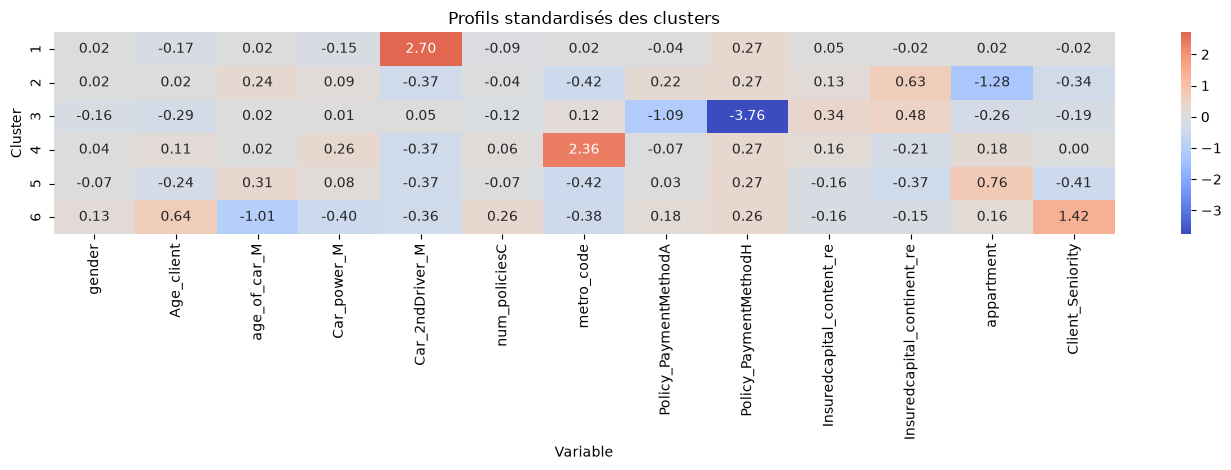

In [118]:
plt.figure(
    figsize=(
        14,
        max(
            4,
            best_k_silhouette * 0.8
        )
    )
)

sns.heatmap(
    cluster_centers,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Profils standardisés des clusters"
)
plt.xlabel("Variable")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

In [119]:
cluster_risk_summary = (
    clustering_data
    .groupby("Cluster_Label")
    .agg(
        Nombre_contrats=(
            "PolID",
            "nunique"
        ),
        Probabilite_moyenne=(
            "Predicted_Claim_Probability",
            "mean"
        ),
        Frequence_moyenne=(
            "Predicted_Frequency",
            "mean"
        ),
        Severite_moyenne=(
            "Predicted_Severity",
            "mean"
        ),
        Cout_attendu_moyen=(
            "Predicted_Expected_Cost",
            "mean"
        ),
        Cout_attendu_total=(
            "Predicted_Expected_Cost",
            "sum"
        ),
        Decile_moyen=(
            "Risk_Decile",
            "mean"
        )
    )
)

cluster_risk_summary.round(3)

,Nombre_contrats,Probabilite_moyenne,Frequence_moyenne,Severite_moyenne,Cout_attendu_moyen,Cout_attendu_total,Decile_moyen
Cluster_Label,,,,,,,
1,1470,0.431,0.065,762.425,40.240,59153.124,7.052
2,2930,0.300,0.065,853.091,36.910,108147.217,6.277
3,876,0.416,0.065,819.443,41.310,36187.982,7.268
4,1582,0.378,0.065,759.022,31.510,49848.927,4.910
5,4336,0.487,0.066,725.660,34.142,148040.131,5.674
6,2090,0.377,0.064,686.135,23.173,48431.265,2.662


In [120]:
cluster_risk_plot = (
    cluster_risk_summary
    .reset_index()
)

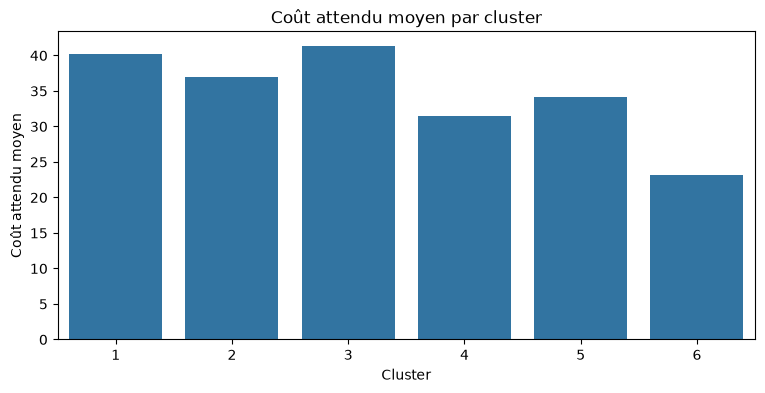

In [121]:
plt.figure(figsize=(9, 4))

sns.barplot(
    data=cluster_risk_plot,
    x="Cluster_Label",
    y="Cout_attendu_moyen"
)

plt.title(
    "Coût attendu moyen par cluster"
)
plt.xlabel("Cluster")
plt.ylabel("Coût attendu moyen")
plt.show()

In [122]:
risk_level_by_cluster = pd.crosstab(
    clustering_data[
        "Cluster_Label"
    ],
    clustering_data[
        "Risk_Level"
    ],
    normalize="index"
).mul(100)

In [123]:
risk_level_by_cluster = (
    risk_level_by_cluster.reindex(
        columns=[
            "Faible",
            "Moyen",
            "Élevé"
        ],
        fill_value=0
    )
)

risk_level_by_cluster.round(2)

Risk_Level,Faible,Moyen,Élevé
Cluster_Label,,,
1,18.57,29.59,51.84
2,28.05,34.98,36.96
3,15.75,29.00,55.25
4,48.42,28.70,22.88
5,36.28,34.71,29.01
6,83.35,14.93,1.72


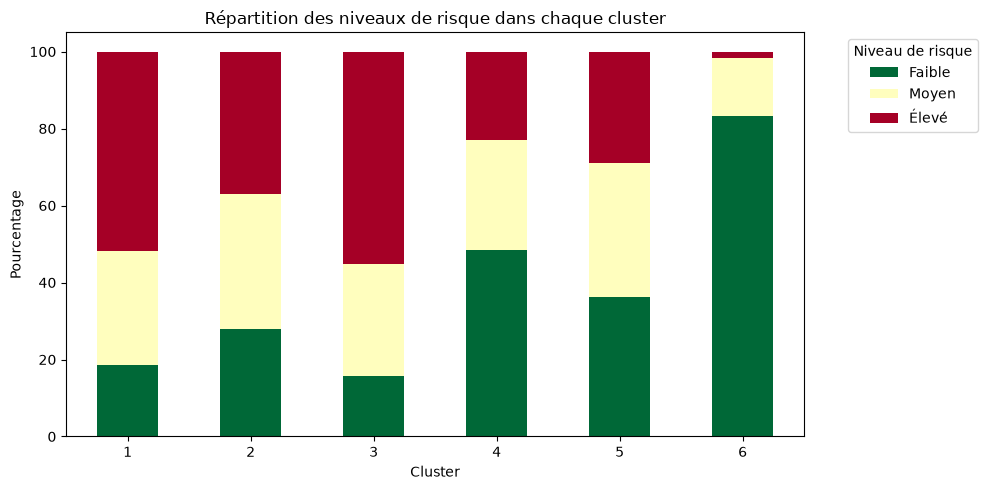

In [124]:
risk_level_by_cluster.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    colormap="RdYlGn_r"
)

plt.title(
    "Répartition des niveaux de risque "
    "dans chaque cluster"
)
plt.xlabel("Cluster")
plt.ylabel("Pourcentage")
plt.legend(
    title="Niveau de risque",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [125]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_clustering_scaled
)

In [126]:
explained_variance = (
    pca.explained_variance_ratio_
    * 100
)

print(
    "Variance expliquée par PC1 : "
    f"{explained_variance[0]:.2f}%"
)

print(
    "Variance expliquée par PC2 : "
    f"{explained_variance[1]:.2f}%"
)

print(
    "Variance totale des deux axes : "
    f"{explained_variance.sum():.2f}%"
)

Variance expliquée par PC1 : 12.86%
Variance expliquée par PC2 : 12.00%
Variance totale des deux axes : 24.86%


In [127]:
pca_visualization = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": (
        clustering_data[
            "Cluster_Label"
        ].to_numpy()
    )
})

In [128]:
pca_plot_sample = (
    pca_visualization.sample(
        n=min(
            10000,
            len(pca_visualization)
        ),
        random_state=42
    )
)

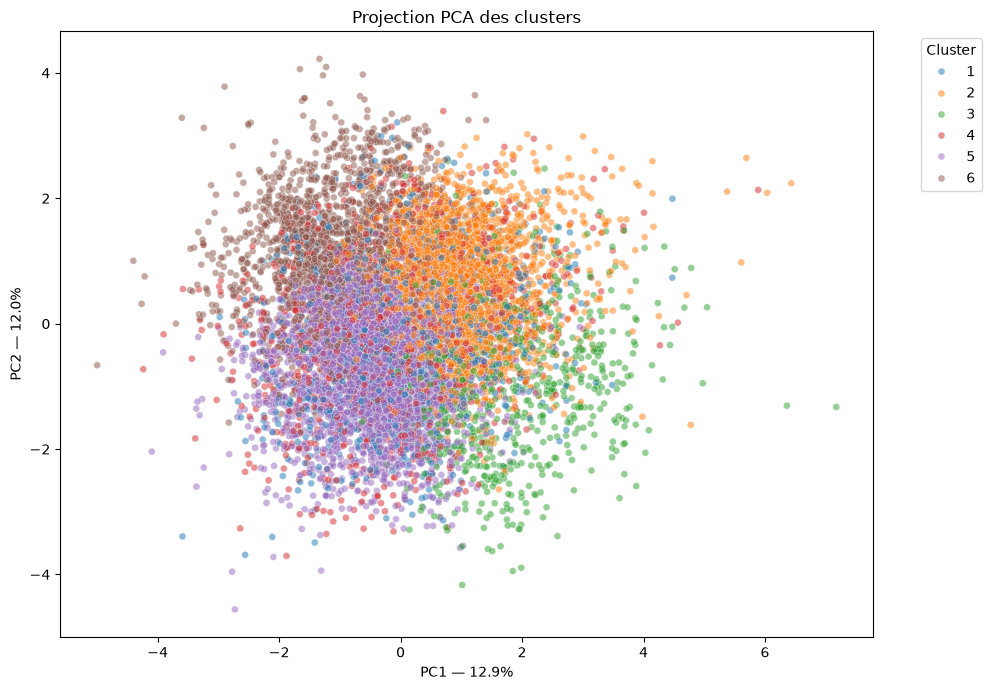

In [129]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_plot_sample,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.5,
    s=25
)

plt.title(
    "Projection PCA des clusters"
)
plt.xlabel(
    f"PC1 — {explained_variance[0]:.1f}%"
)
plt.ylabel(
    f"PC2 — {explained_variance[1]:.1f}%"
)
plt.legend(
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [130]:
cluster_output_columns = [
    "PolID",
    "year",
    "Cluster_Label",
    "Predicted_Claim_Probability",
    "Predicted_Frequency",
    "Predicted_Severity",
    "Predicted_Expected_Cost",
    "Risk_Decile",
    "Risk_Level"
]

In [131]:
cluster_assignments = clustering_data[
    cluster_output_columns
].copy()

In [132]:
cluster_output_path = Path(
    "../data/processed/cluster_assignments_year5.csv"
)

cluster_assignments.to_csv(
    cluster_output_path,
    index=False
)

print(
    f"Clusters enregistrés dans : "
    f"{cluster_output_path}"
)

Clusters enregistrés dans : ..\data\processed\cluster_assignments_year5.csv


## Construction des groupes collaboratifs

Chaque groupe contiendra approximativement 50 assurés.

Les groupes sont construits à l’intérieur des clusters afin de conserver la similarité des profils. Une allocation gloutonne répartit ensuite les contrats selon leur coût attendu pour limiter la concentration du risque.

In [133]:
target_group_size = 50

In [134]:
def assign_balanced_groups(
    cluster_data,
    target_size=50
):
    local_data = (
        cluster_data
        .sort_values(
            by="Predicted_Expected_Cost",
            ascending=False
        )
        .copy()
    )

    number_of_members = len(local_data)

    number_of_groups = max(
        1,
        int(
            np.floor(
                number_of_members
                / target_size
                + 0.5
            )
        )
    )

    base_capacity = (
        number_of_members
        // number_of_groups
    )

    remaining_members = (
        number_of_members
        % number_of_groups
    )

    capacities = np.full(
        number_of_groups,
        base_capacity,
        dtype=int
    )

    capacities[
        :remaining_members
    ] += 1

    group_costs = np.zeros(
        number_of_groups
    )

    group_counts = np.zeros(
        number_of_groups,
        dtype=int
    )

    assignments = []

    for expected_cost in local_data[
        "Predicted_Expected_Cost"
    ]:
        eligible_groups = np.where(
            group_counts < capacities
        )[0]

        eligible_costs = group_costs[
            eligible_groups
        ]

        selected_group = (
            eligible_groups[
                np.argmin(
                    eligible_costs
                )
            ]
        )

        assignments.append(
            selected_group + 1
        )

        group_costs[
            selected_group
        ] += expected_cost

        group_counts[
            selected_group
        ] += 1

    local_data[
        "Local_Group"
    ] = assignments

    cluster_label = int(
        local_data[
            "Cluster_Label"
        ].iloc[0]
    )

    local_data[
        "Collaborative_Group"
    ] = local_data[
        "Local_Group"
    ].apply(
        lambda group_number: (
            f"C{cluster_label:02d}"
            f"_G{group_number:03d}"
        )
    )

    return local_data

In [135]:
collaborative_group_parts = []

for cluster_label in sorted(
    clustering_data[
        "Cluster_Label"
    ].unique()
):
    cluster_subset = clustering_data[
        clustering_data[
            "Cluster_Label"
        ] == cluster_label
    ].copy()

    assigned_subset = (
        assign_balanced_groups(
            cluster_data=cluster_subset,
            target_size=target_group_size
        )
    )

    collaborative_group_parts.append(
        assigned_subset
    )

In [136]:
collaborative_groups = pd.concat(
    collaborative_group_parts,
    ignore_index=True
)

In [137]:
print(
    "Nombre de contrats affectés :",
    len(collaborative_groups)
)

print(
    "Nombre de groupes créés :",
    collaborative_groups[
        "Collaborative_Group"
    ].nunique()
)

Nombre de contrats affectés : 13284
Nombre de groupes créés : 267


In [138]:
assert (
    len(collaborative_groups)
    == len(clustering_data)
)

assert not collaborative_groups[
    "Collaborative_Group"
].isnull().any()

print(
    "Tous les contrats ont été affectés "
    "à un groupe collaboratif."
)

Tous les contrats ont été affectés à un groupe collaboratif.


In [139]:
collaborative_group_summary = (
    collaborative_groups
    .groupby(
        [
            "Cluster_Label",
            "Collaborative_Group"
        ]
    )
    .agg(
        Nombre_membres=(
            "PolID",
            "nunique"
        ),
        Probabilite_moyenne=(
            "Predicted_Claim_Probability",
            "mean"
        ),
        Frequence_moyenne=(
            "Predicted_Frequency",
            "mean"
        ),
        Severite_moyenne=(
            "Predicted_Severity",
            "mean"
        ),
        Cout_attendu_moyen=(
            "Predicted_Expected_Cost",
            "mean"
        ),
        Cout_attendu_total=(
            "Predicted_Expected_Cost",
            "sum"
        )
    )
    .reset_index()
)

collaborative_group_summary.head()

,Cluster_Label,Collaborative_Group,Nombre_membres,Probabilite_moyenne,Frequence_moyenne,Severite_moyenne,Cout_attendu_moyen,Cout_attendu_total
0,1,C01_G001,51,0.412029,0.065318,770.716190,40.069220,2043.530224
1,1,C01_G002,51,0.441251,0.065438,752.002643,40.100462,2045.123583
2,1,C01_G003,51,0.438019,0.065359,762.177887,40.123898,2046.318775
3,1,C01_G004,51,0.418369,0.065449,760.237116,40.096186,2044.905482
4,1,C01_G005,51,0.431583,0.065356,764.290468,40.125341,2046.392404


In [140]:
group_size_statistics = (
    collaborative_group_summary[
        "Nombre_membres"
    ].describe()
)

group_size_statistics

count    267.000000
mean      49.752809
std        0.618285
min       48.000000
25%       49.000000
50%       50.000000
75%       50.000000
max       51.000000
Name: Nombre_membres, dtype: float64

In [141]:
print(
    "Taille minimale :",
    collaborative_group_summary[
        "Nombre_membres"
    ].min()
)

print(
    "Taille moyenne :",
    collaborative_group_summary[
        "Nombre_membres"
    ].mean()
)

print(
    "Taille maximale :",
    collaborative_group_summary[
        "Nombre_membres"
    ].max()
)

Taille minimale : 48
Taille moyenne : 49.752808988764045
Taille maximale : 51


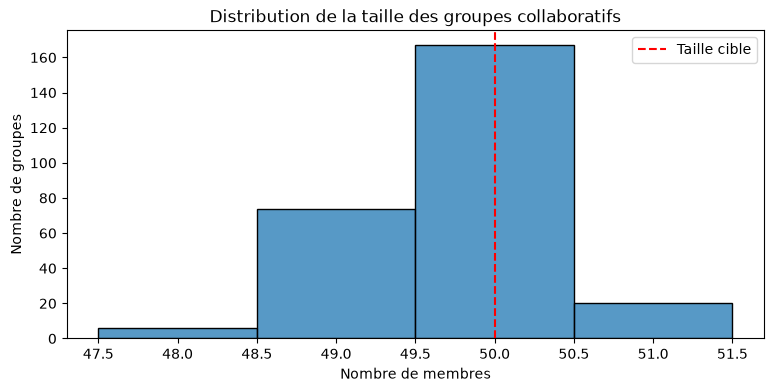

In [142]:
plt.figure(figsize=(9, 4))

sns.histplot(
    data=collaborative_group_summary,
    x="Nombre_membres",
    discrete=True
)

plt.axvline(
    x=target_group_size,
    color="red",
    linestyle="--",
    label="Taille cible"
)

plt.title(
    "Distribution de la taille "
    "des groupes collaboratifs"
)
plt.xlabel("Nombre de membres")
plt.ylabel("Nombre de groupes")
plt.legend()
plt.show()

In [143]:
clusters_per_group = (
    collaborative_groups
    .groupby(
        "Collaborative_Group"
    )["Cluster_Label"]
    .nunique()
)

clusters_per_group.value_counts()

Cluster_Label
1    267
Name: count, dtype: int64

In [144]:
assert (
    clusters_per_group == 1
).all()

print(
    "Chaque groupe contient uniquement "
    "des membres du même cluster."
)

Chaque groupe contient uniquement des membres du même cluster.


In [145]:
risk_balance_by_cluster = (
    collaborative_group_summary
    .groupby("Cluster_Label")
    .agg(
        Nombre_groupes=(
            "Collaborative_Group",
            "nunique"
        ),
        Cout_total_moyen=(
            "Cout_attendu_total",
            "mean"
        ),
        Cout_total_ecart_type=(
            "Cout_attendu_total",
            "std"
        ),
        Cout_total_minimum=(
            "Cout_attendu_total",
            "min"
        ),
        Cout_total_maximum=(
            "Cout_attendu_total",
            "max"
        )
    )
)

In [146]:
risk_balance_by_cluster[
    "Coefficient_variation"
] = (
    risk_balance_by_cluster[
        "Cout_total_ecart_type"
    ]
    / risk_balance_by_cluster[
        "Cout_total_moyen"
    ]
)

In [147]:
risk_balance_by_cluster.round(3)

,Nombre_groupes,Cout_total_moyen,Cout_total_ecart_type,Cout_total_minimum,Cout_total_maximum,Coefficient_variation
Cluster_Label,,,,,,
1,29,2039.763,8.703,2026.484,2046.392,0.004
2,59,1833.004,10.155,1818.989,1851.751,0.006
3,18,2010.443,11.551,1995.415,2028.591,0.006
4,32,1557.779,6.722,1550.988,1572.722,0.004
5,87,1701.611,5.843,1687.811,1705.210,0.003
6,42,1153.125,4.781,1144.436,1156.843,0.004


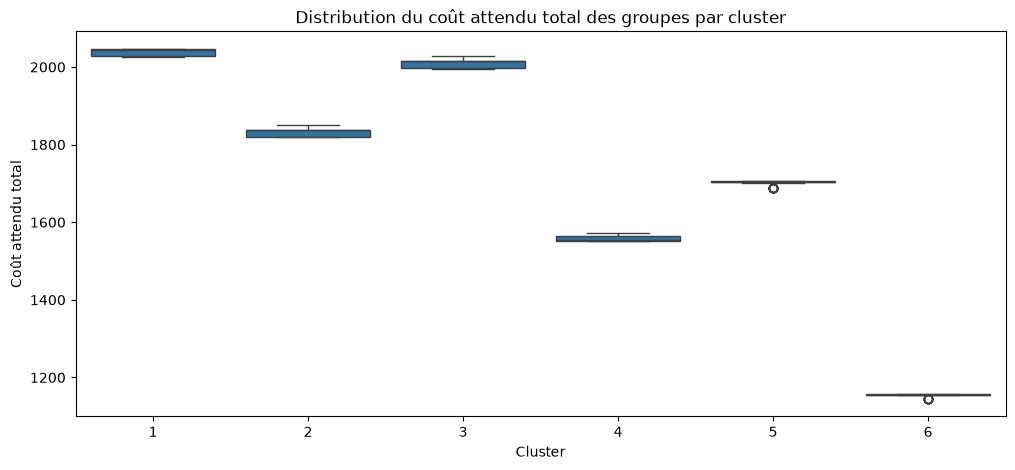

In [148]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=collaborative_group_summary,
    x="Cluster_Label",
    y="Cout_attendu_total"
)

plt.title(
    "Distribution du coût attendu total "
    "des groupes par cluster"
)
plt.xlabel("Cluster")
plt.ylabel("Coût attendu total")
plt.show()

In [149]:
example_cluster = int(
    collaborative_group_summary
    .groupby("Cluster_Label")[
        "Collaborative_Group"
    ]
    .nunique()
    .idxmax()
)

print(
    f"Cluster illustré : {example_cluster}"
)

Cluster illustré : 5


In [150]:
example_cluster_groups = (
    collaborative_group_summary[
        collaborative_group_summary[
            "Cluster_Label"
        ] == example_cluster
    ]
)

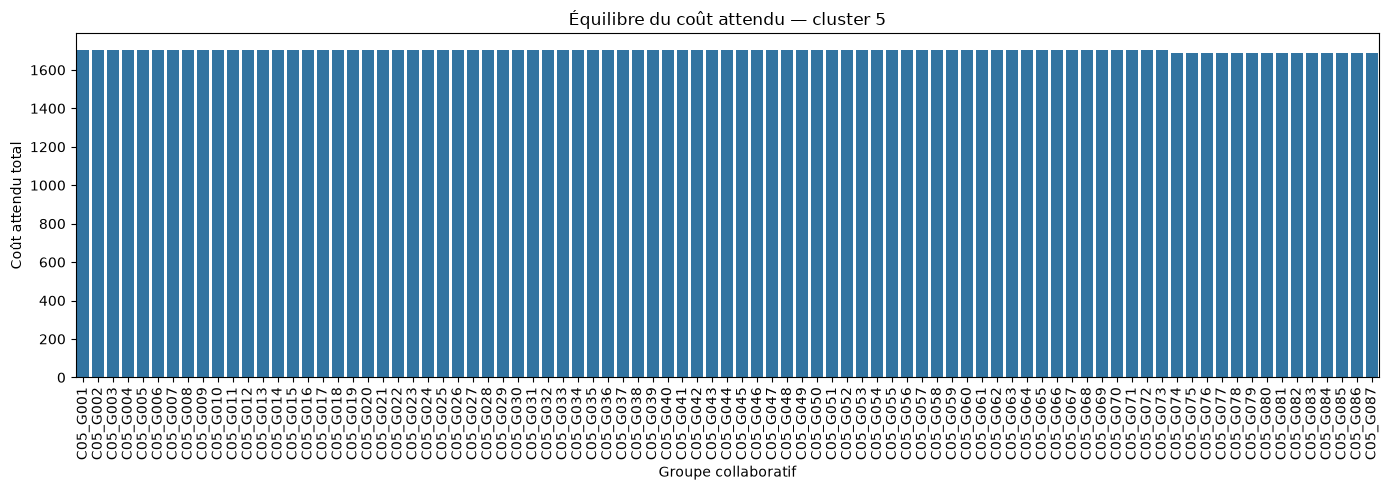

In [151]:
plt.figure(figsize=(14, 5))

sns.barplot(
    data=example_cluster_groups,
    x="Collaborative_Group",
    y="Cout_attendu_total"
)

plt.title(
    f"Équilibre du coût attendu — "
    f"cluster {example_cluster}"
)
plt.xlabel("Groupe collaboratif")
plt.ylabel("Coût attendu total")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [152]:
final_group_columns = [
    "PolID",
    "year",
    "Cluster_Label",
    "Collaborative_Group",
    "Predicted_Claim_Probability",
    "Predicted_Frequency",
    "Predicted_Severity",
    "Predicted_Expected_Cost",
    "Risk_Decile",
    "Risk_Level"
]

In [153]:
final_group_assignments = (
    collaborative_groups[
        final_group_columns
    ]
    .sort_values(
        by=[
            "Cluster_Label",
            "Collaborative_Group",
            "Predicted_Expected_Cost"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
)

In [78]:
group_assignments_path = Path(
    "../data/processed/"
    "collaborative_group_assignments.csv"
)

final_group_assignments.to_csv(
    group_assignments_path,
    index=False
)

print(
    f"Affectations enregistrées dans : "
    f"{group_assignments_path}"
)

Affectations enregistrées dans : ..\data\processed\collaborative_group_assignments.csv


In [154]:
group_summary_path = Path(
    "../data/processed/"
    "collaborative_group_summary.csv"
)

collaborative_group_summary.to_csv(
    group_summary_path,
    index=False
)

print(
    f"Résumé enregistré dans : "
    f"{group_summary_path}"
)

Résumé enregistré dans : ..\data\processed\collaborative_group_summary.csv


In [155]:
evaluation_columns = [
    "Total_NClaims",
    "Total_Claims",
    "Has_Claim"
]

for column in evaluation_columns:
    print(
        column,
        column in collaborative_groups.columns
    )

Total_NClaims True
Total_Claims True
Has_Claim True


In [156]:
real_outcomes_year5 = year5_profiles[
    [
        "PolID",
        "year",
        "Has_Claim",
        "Total_NClaims",
        "Total_Claims"
    ]
].copy()

In [157]:
collaborative_groups = (
    collaborative_groups.merge(
        real_outcomes_year5,
        on=["PolID", "year"],
        how="left",
        validate="one_to_one"
    )
)

In [158]:
random_generator = (
    np.random.default_rng(42)
)

random_assignment_data = (
    collaborative_groups.copy()
)

random_assignment_data[
    "Random_Group"
] = ""

In [159]:
for cluster_label in sorted(
    random_assignment_data[
        "Cluster_Label"
    ].unique()
):
    cluster_indices = (
        random_assignment_data[
            random_assignment_data[
                "Cluster_Label"
            ] == cluster_label
        ].index
    )

    existing_group_labels = (
        random_assignment_data.loc[
            cluster_indices,
            "Collaborative_Group"
        ]
        .to_numpy()
        .copy()
    )

    random_generator.shuffle(
        existing_group_labels
    )

    random_assignment_data.loc[
        cluster_indices,
        "Random_Group"
    ] = existing_group_labels

In [160]:
optimized_sizes = (
    collaborative_groups
    .groupby("Collaborative_Group")
    .size()
    .sort_values()
    .to_numpy()
)

random_sizes = (
    random_assignment_data
    .groupby("Random_Group")
    .size()
    .sort_values()
    .to_numpy()
)

In [161]:
assert np.array_equal(
    optimized_sizes,
    random_sizes
)

print(
    "Les deux méthodes possèdent "
    "exactement les mêmes tailles."
)

Les deux méthodes possèdent exactement les mêmes tailles.


In [164]:
def summarize_groups(
    data,
    group_column,
    method_name
):
    summary = (
        data
        .groupby(
            [
                "Cluster_Label",
                group_column
            ]
        )
        .agg(
            Nombre_membres=(
                "PolID",
                "nunique"
            ),
            Probabilite_moyenne=(
                "Predicted_Claim_Probability",
                "mean"
            ),
            Cout_attendu_moyen=(
                "Predicted_Expected_Cost",
                "mean"
            ),
            Cout_attendu_total=(
                "Predicted_Expected_Cost",
                "sum"
            ),
            Nombre_reel_sinistres=(
                "Total_NClaims",
                "sum"
            ),
            Cout_reel_total=(
                "Total_Claims",
                "sum"
            ),
            Cout_reel_moyen=(
                "Total_Claims",
                "mean"
            )
        )
        .reset_index()
    )

    summary = summary.rename(
        columns={
            group_column: "Groupe"
        }
    )

    summary["Methode"] = method_name

    return summary

In [181]:
optimized_group_evaluation = (
    summarize_groups(
        data=collaborative_groups,
        group_column="Collaborative_Group",
        method_name="Équilibrée"
    )
)

In [182]:
random_group_evaluation = (
    summarize_groups(
        data=random_assignment_data,
        group_column="Random_Group",
        method_name="Aléatoire"
    )
)

KeyError: "Label(s) ['Total_Claims', 'Total_NClaims'] do not exist"